In [1]:
import os

import matplotlib.pyplot as plt

import components.broadcast_components.broadcasting_process.broadcast_reporting_utilities
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import plot_stats
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
import components.broadcast_components.broadcasting_process.WZ_broadcast

import numpy as np
import gzip
import torch
import pickle
import importlib

torch.set_float32_matmul_precision('medium')

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [2]:
grad_list_rid_wid = []
for rid in range(6):
# for rid in range(len(os.listdir('exp_data/save_grads_per_round'))//2):
    grad_list_rid_wid.append([])
    for wid in range(2):
        path_to_file = f'exp_data/save_grads_per_round/grad_round_{rid}_worker_{wid}.pkl.gz'
        with gzip.open(path_to_file, 'rb') as f:
            grad_list_rid_wid[-1].append({k: a.cpu() for k, a in pickle.load(f).items()})

In [3]:
model_shape_dict = {k:v.numpy().shape for k, v in grad_list_rid_wid[0][0].items()}

In [4]:
importlib.reload(components.broadcast_components.broadcasting_process.WZ_broadcast)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(components.broadcast_components.broadcasting_process.broadcast_reporting_utilities)
from components.broadcast_components.broadcasting_process.WZ_broadcast import WZBroadcastProtocol
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import BroadcastMetricGatheringUtilities
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN

import random
random.seed(101)
np.random.seed(101)

worker_count = 2

wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=2, bins_per_plane=16, tau=1.5,
                                 reconst_ld=400, lr=1e-3, tau_rate=10, marginal=True).to(torch.float32)
wz_model.load_state_dict(torch.load('../data/basicRNN_2plane_4bins_state.pt', map_location='cpu'))
base_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=0, enable_progress_bar=True)
broadcast_prot_base = WZBroadcastProtocol(worker_count, base_quantizer)
broadcast_prot = BroadcastMetricGatheringUtilities(broadcast_prot_base)

for round, grad_per_round in enumerate(grad_list_rid_wid):
    # if round == 1: break
    if round == 6: break

    for ag_id, grad in enumerate(grad_per_round):
        broadcast_prot.start_round_agent_process(ag_id, round)

        print(f'>> Round {round}, Agent {ag_id}')
        _ = broadcast_prot.model_transfer_to_worker_from_server(grad)

        print('          - Preparing data for transfer to worker...')
        server_data_sent_to_worker = broadcast_prot.to_worker_prep_data_for_transfer(ag_id)

        print('          - Preparing data for transfer to server...')
        encoded_ag_broadcast = broadcast_prot.to_server_prep_data_for_transfer(
                        ag_id, grad, server_data_sent_to_worker)

        print('          - reconstructing data received...')
        decoded_agent_broadcast = broadcast_prot.reconstruction_process(
            ag_id, encoded_ag_broadcast, worker_count, model_shape_dict)

          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

>> Round 4, Agent 1
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

>> Round 5, Agent 0
        - training quant for global model transfer
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

>> Round 5, Agent 1
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

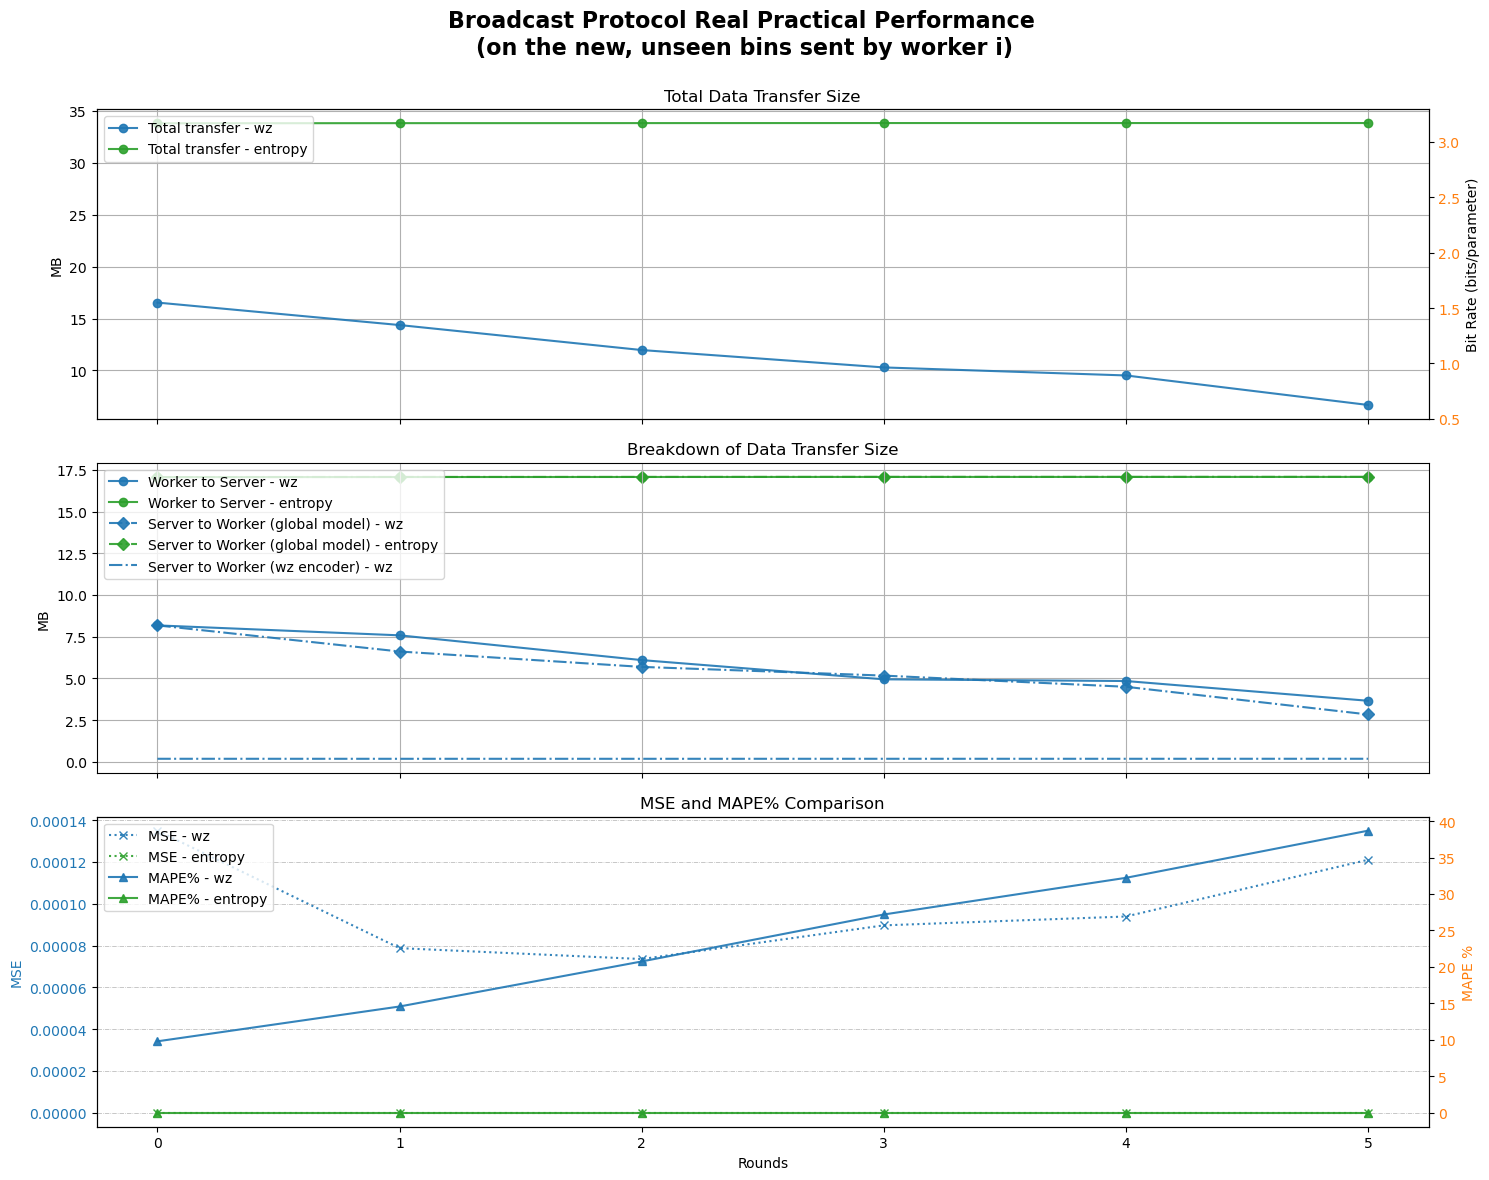

In [7]:
import components.broadcast_components.broadcasting_process.broadcast_reporting_utilities
importlib.reload(components.broadcast_components.broadcasting_process.broadcast_reporting_utilities)
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import plot_stats
plot_stats(broadcast_prot.entire_stats, no_raw=True)

In [6]:
raise

RuntimeError: No active exception to reraise

In [ ]:
from components.broadcast_components.broadcasting_process.WZ_broadcast import dict_to_array, normalize_array_data
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
from components.broadcast_components.WZ_models.wz_quant_ANN import plot_bins

def f(grad_dict):
    shapes_dict = {k: v.shape for k, v in grad_dict.items()}
    grad_flat = dict_to_array(grad_dict)
    grad_flat_normal, norm_fact_vec = normalize_array_data(
        grad_flat, shapes_dict, outlier_rem=False, normalize=True)

    # Separate outliers with abs value > 2
    outlier_mask = np.abs(grad_flat_normal) > broadcast_prot.outlier_threshold
    outlier_values = grad_flat_normal[outlier_mask]

    # normalize the outlier values
    outlier_values = (np.abs(outlier_values)-broadcast_prot.outlier_threshold)*np.sign(outlier_values)
    outlier_max = np.percentile(np.abs(outlier_values), 99.99)/broadcast_prot.outlier_threshold
    grad_flat_normal[outlier_mask] = outlier_values / outlier_max
    return grad_flat_normal

wz_quantizer:WZQuantizer = broadcast_prot.wz_quantizer_list[0]

y=f(grad_list_rid_wid[1][0])
prev_targ_real=f(grad_list_rid_wid[0][0])
prev_targ_at_serv=broadcast_prot.prev_d_flat[0]+np.random.normal(0, np.sqrt(1e-6), len(y), ).astype(np.float32)
side_info = broadcast_prot.prev_d_flat[:0] + broadcast_prot.prev_d_flat[0 + 1:]

plt.figure(figsize=(12, 3))
temp = prev_targ_real+np.random.normal(0, np.sqrt(1e-4), len(prev_targ_real), ).astype(np.float32)
plt.hist(y,         bins=200, alpha=0.5, label='y', density=1)
plt.hist(temp,      bins=200, alpha=0.5, label='prev_targ_real', density=1)
plt.hist(side_info, bins=200, alpha=0.5, label='side_info', density=1)
plt.legend()
plt.ylim(0,5)

In [ ]:
print('how well the intended next agent grad is recons (y)')
plot_bins(wz_quantizer, y, side_info, step_count=min(len(temp), 10_000))
print('how well the trained data is reconstructed (prev_targ_at_serv)')
plot_bins(wz_quantizer, prev_targ_at_serv, side_info, step_count=min(len(temp), 10_000))
print('how well the original continues training data is recons (prev_targ_real)')
plot_bins(wz_quantizer, prev_targ_real, side_info, step_count=min(len(temp), 10_000))